# The Climate is Changing: How is Our Sentiment?

## Exploring Changing Sentiment in Climate Articles: 2013 to 2023

### Imports and Setup

In [73]:
# General mports
import os
import sys

# NLTK
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
nltk.download('stopwords')
#print(stopwords.words('english'))


# ----File Stitching----
# If not in notebooks folder, cd into it
if os.path.basename(os.getcwd()) != "notebooks":
    os.chdir('./notebooks/')
# If a file is in /sources/, access it by telling the system to look at that path as well as current path
sys.path.append(os.path.join(os.getcwd(), '..', 'sources'))
# A check
os.getcwd()

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/Caroline/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


'/Users/Caroline/Desktop/school/text_as_data/evolving_sentiment_climate/notebooks'

In [17]:
# General imports
import numpy as np 
import pandas as pd 
import os
from collections import Counter
import re

# XML data
from bs4 import BeautifulSoup
import xml.etree.ElementTree as ET
import lxml

# Plotting
import plotly.express as px
import plotly.io as pio
import matplotlib.pyplot as plt

# Gensim and TSNE
from gensim.corpora import Dictionary
from gensim.models import word2vec

# SKLearn
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.manifold import TSNE as tsne

In [7]:
%run data_extraction.ipynb

In [72]:
%run initial_exploration.iypnb

Exception: File `'initial_exploration.iypnb'` not found.

### Combine then Split TOKEN Table by Year

In [ ]:
# Import from data extraction notebook
TOKEN

token_str      term_str
doc_id token_num                            
0      0            Scientific    scientific
       1                impact        impact
       2              measures      measures
       3                   are           are
       4          increasingly  increasingly
...                        ...           ...
8      15801               its           its
       15802         continued     continued
       15803          progress      progress
       15804               and           and
       15805          success.       success

[57027 rows x 2 columns]

In [ ]:
# Replace TOKEN.index = TOKEN.index.set_levels([2013, 2013, 2013, 2018, 2018, 2018, 2023, 2023, 2023], level=0) with below (Claude)
mapping = {0:2013, 1:2013, 2:2013, 3:2018, 4:2018, 5:2018, 6:2023, 7:2023, 8:2023}
TOKEN.index = TOKEN.index.map(lambda x: (mapping[x[0]], x[1]))
TOKEN

token_str      term_str
doc_id token_num                            
2013   0            Scientific    scientific
       1                impact        impact
       2              measures      measures
       3                   are           are
       4          increasingly  increasingly
...                        ...           ...
2023   15801               its           its
       15802         continued     continued
       15803          progress      progress
       15804               and           and
       15805          success.       success

[57027 rows x 2 columns]

In [ ]:
TOKEN_2013 = TOKEN[TOKEN.index, level = 0 == '2013']
TOKEN_2018 = TOKEN[TOKEN.index == '2018']
TOKEN_2023 = TOKEN[TOKEN.index == '2023']

TOKENS = [TOKEN_2013, TOKEN_2018, TOKEN_2023]

# Drop na
for token in TOKENS:
    token = token.dropna()

SyntaxError: invalid syntax. Maybe you meant '==' or ':=' instead of '='? (4261324952.py, line 1)

In [83]:
TOKEN_2013

,,token_str,term_str
doc_id,token_num,,


### Plot Top Vocab Words

In [78]:
def plot_top_vocab_words(token):
    # Join tokens into one string per doc_id (Claude)
    docs = token.groupby(level=0)['term_str'].apply(' '.join)

    # Create engine, model
    engine = CountVectorizer()
    model = engine.fit_transform(token['term_str']) # Claude suggested this, passes as series so it's accepted by CountVectorizer()

    # Extract count matrix
    ct = engine.get_feature_names_out()

    # Data frame
    X = pd.DataFrame(model.toarray(), columns=ct)
    X.index.name = 'doc_id'
    
    return X

for token in TOKENS:
    plot_top_vocab_words(token)

ValueError: empty vocabulary; perhaps the documents only contain stop words

In [47]:
X.T

doc_id,2013,2018,2023
abbreviations,2,0,1
abies,1,0,0
abilities,0,0,1
ability,1,5,8
abiotic,5,5,0
...,...,...,...
zones,1,0,2
zoonotic,0,0,1
zoopagomycota,1,0,0
zygomycetes,1,0,0


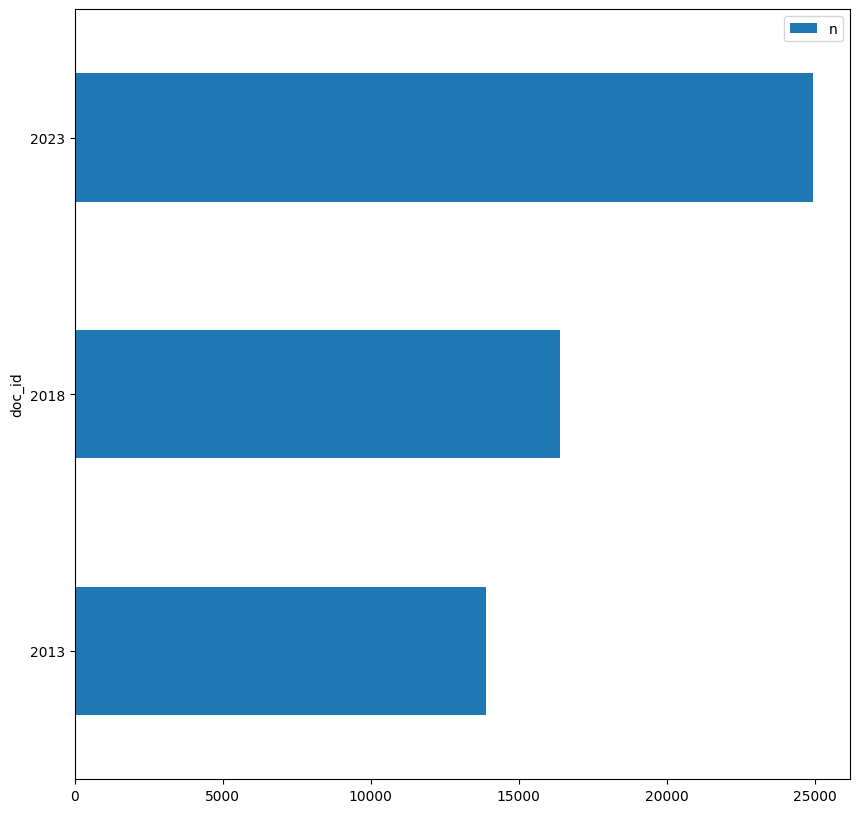

In [ ]:
# Quick look at length of documents with stopwords
len = X.T.sum().to_frame('n')
# Show stats
len.sort_values('n').plot.barh(figsize=(10,10))
plt.show()

In [74]:
# Quick look at documents without stopwords
stop_words = set(stopwords.words('english'))
word_tokens = word_tokenize(X)


LookupError: 
**********************************************************************
  Resource 'punkt_tab' not found.
  Please use the NLTK Downloader to obtain the resource:

  >>> import nltk
  >>> nltk.download('punkt_tab')

  For more information see: https://www.nltk.org/data.html

  Attempted to load 'tokenizers/punkt_tab/english/'

  Searched in:
    - '/Users/Caroline/nltk_data'
    - '/Users/Caroline/miniconda3/envs/text_as_data/nltk_data'
    - '/Users/Caroline/miniconda3/envs/text_as_data/share/nltk_data'
    - '/Users/Caroline/miniconda3/envs/text_as_data/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
**********************************************************************


Observation: Articles get longer over time, at least in this sample of documents.

In [69]:
X

,abbreviations,abies,abilities,ability,abiotic,able,abm,about,above,abs,...,zi,zinc,zksnarks,zkstarks,zn,zones,zoonotic,zoopagomycota,zygomycetes,zygomycota
doc_id,,,,,,,,,,,,,,,,,,,,,
2013,2,1,0,1,5,3,9,12,3,0,...,0,0,0,0,2,1,0,1,1,1
2018,0,0,0,5,5,2,0,3,11,1,...,0,1,0,0,0,0,0,0,0,0
2023,1,0,1,8,0,4,0,11,5,0,...,2,0,6,4,0,2,1,0,0,0


### Explore Word Distribution Over Time

In [ ]:
def plot_words(words):
    window = int(n_chunks / 10)
    ax = CHUNK[words.split(",")].rolling(window).mean().plot(kind='line', figsize=(20,5), lw=3)
    ax.axhline(CHUNK['anne'].mean(), ls='--', color='gray', lw=2)
    sns.despine()
    plt.title(words)
    plt.show()